The objective of this notebook is to understand the data and to find the sweet spot for the number of characters to keep.

### **Notebook plan**
1) Load + sanity-check  
2) Clean (strip names, remove empty lines, fix dtypes) ~ data already clean, there is only duplicates  
3) Global stats
4) Per-season analysis (#characters, #lines)  
5) Character summary (`num_lines`, `num_episodes`, `num_seasons`)  
6) plots top-15 characters per lines seasons and episodes
7) Sweet spot: top-K coverage curves + decision table  
8) Choose K automatically + output selected characters  

In [2]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [3]:
base_url = "https://raw.githubusercontent.com/BobAdamsEE/SouthParkData/refs/heads/master/by-season/Season-{}.csv"
dfs = []
for season in range(1, 20):  # saisons 1 to 19
    url = base_url.format(season)
    dfs.append(pd.read_csv(url))

df = pd.concat(dfs, ignore_index=True)
df.head()

,Season,Episode,Character,Line
0,1,1,Boys,"School day, school day, teacher's golden ru...\n"
1,1,1,Kyle,"Ah, damn it! My little brother's trying to fol..."
2,1,1,Ike,Zeeponanner.\n
3,1,1,Kyle,"Ike, you can't come to school with me. \n"
4,1,1,Cartman,"Yeah, go home you little dildo.\n"


#### df peak

In [4]:
df.head()

,Season,Episode,Character,Line
0,1,1,Boys,"School day, school day, teacher's golden ru...\n"
1,1,1,Kyle,"Ah, damn it! My little brother's trying to fol..."
2,1,1,Ike,Zeeponanner.\n
3,1,1,Kyle,"Ike, you can't come to school with me. \n"
4,1,1,Cartman,"Yeah, go home you little dildo.\n"


In [5]:
required_cols = ["Season", "Episode", "Character", "Line"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")
print("✅ Required columns exist:", required_cols)

✅ Required columns exist: ['Season', 'Episode', 'Character', 'Line']


In [7]:
# null values ?
df[required_cols].isna().sum().sort_values(ascending=False)

,0
Season,0
Episode,0
Character,0
Line,0


In [14]:
df.duplicated(subset=required_cols).sum()

np.int64(901)

## Basic check & Cleaning

In [21]:
# %%
df_clean = df.copy()

df_clean["Character"] = df_clean["Character"].astype(str).str.strip()
df_clean["Line"] = df_clean["Line"].astype(str).str.strip()

df_clean["Season"] = pd.to_numeric(df_clean["Season"], errors="coerce")
df_clean["Episode"] = pd.to_numeric(df_clean["Episode"], errors="coerce")

# Drop empty lines
df_clean = df_clean[df_clean["Line"].str.len() > 0]

# Drop rows missing required fields after cleaning
df_clean = df_clean.dropna(subset=required_cols)

# Enforce int types
df_clean["Season"] = df_clean["Season"].astype(int)
df_clean["Episode"] = df_clean["Episode"].astype(int)

df_clean = df_clean.drop_duplicates()

df_clean.head()

,Season,Episode,Character,Line
0,1,1,Boys,"School day, school day, teacher's golden ru..."
1,1,1,Kyle,"Ah, damn it! My little brother's trying to fol..."
2,1,1,Ike,Zeeponanner.
3,1,1,Kyle,"Ike, you can't come to school with me."
4,1,1,Cartman,"Yeah, go home you little dildo."


In [22]:
# %%
print("Rows before:", len(df))
print("Rows after :", len(df_clean))

Rows before: 73139
Rows after : 72079


## Global Stats

In [23]:
n_seasons = df_clean["Season"].nunique()
n_episodes = df_clean[["Season", "Episode"]].drop_duplicates().shape[0]
n_characters = df_clean["Character"].nunique()
n_lines = len(df_clean)

pd.DataFrame(
    {
        "metric": ["#seasons", "#unique episodes", "#characters", "#lines"],
        "value": [n_seasons, n_episodes, n_characters, n_lines],
    }
)

,metric,value
0,#seasons,19
1,#unique episodes,267
2,#characters,4055
3,#lines,72079


## Lines per character

In [24]:
# %%
lines_per_character = df_clean.groupby("Character").size().rename("num_lines")
lines_per_character.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T

,count,mean,std,min,50%,75%,90%,95%,99%,max
num_lines,4055.0,17.775339,237.911592,1.0,2.0,6.0,18.0,33.0,181.38,9895.0


In [27]:
lines_per_character.sort_values(ascending=False).head()

,num_lines
Character,
Cartman,9895
Stan,7667
Kyle,7133
Butters,2687
Randy,2652


# **Season Summary**
---


## Per-season: distinct characters




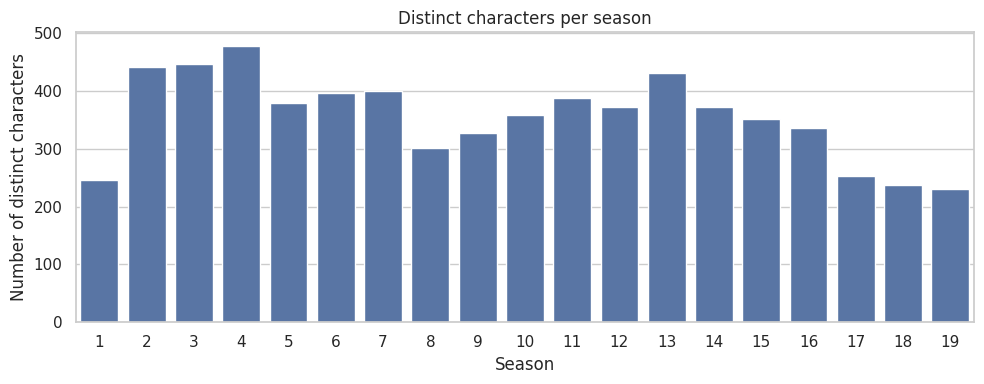

In [28]:
season_characters = (
    df_clean[["Season", "Character"]]
    .drop_duplicates()
    .groupby("Season")
    .size()
    .reset_index(name="num_characters")
)

plt.figure(figsize=(10, 4))
sns.barplot(data=season_characters, x="Season", y="num_characters")
plt.title("Distinct characters per season")
plt.xlabel("Season")
plt.ylabel("Number of distinct characters")
plt.tight_layout()
plt.show()

In [30]:
season_characters.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Season,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
num_characters,247,442,447,478,379,397,400,301,328,359,389,373,432,372,351,336,253,238,231


## Per-season: number of episodes

In [34]:
season_episodes = (
    df_clean[["Season", "Episode"]]
    .drop_duplicates()
    .groupby("Season")
    .size()
    .reset_index(name="num_episodes")
)

season_episodes.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Season,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
num_episodes,13,18,17,17,14,17,15,14,14,14,14,14,14,14,14,14,10,10,10


## Per-season: number of lines

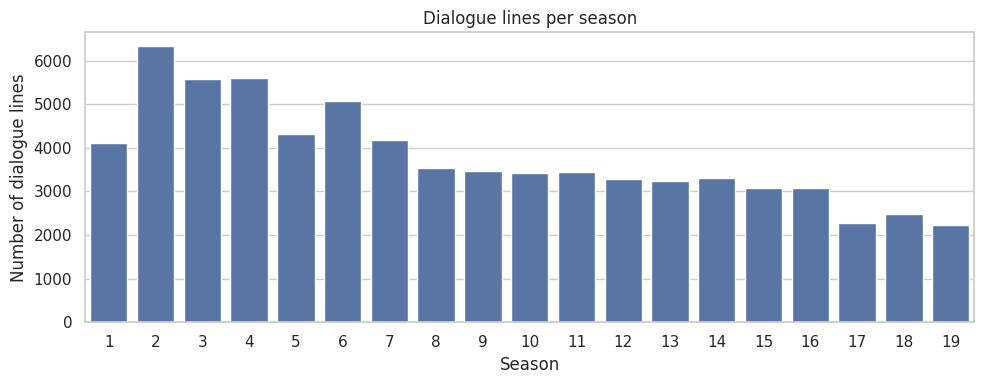

In [31]:
season_lines = df_clean.groupby("Season").size().reset_index(name="num_lines")

plt.figure(figsize=(10, 4))
sns.barplot(data=season_lines, x="Season", y="num_lines")
plt.title("Dialogue lines per season")
plt.xlabel("Season")
plt.ylabel("Number of dialogue lines")
plt.tight_layout()
plt.show()

In [32]:
season_lines.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Season,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
num_lines,4103,6335,5587,5597,4314,5076,4182,3535,3472,3430,3451,3285,3235,3318,3071,3086,2278,2487,2237


# Character Summary
---

In [42]:
base = df_clean.assign(Character=df_clean["Character"].str.strip())

lines = base.groupby("Character").size().rename("num_lines")
episodes = (
    base[["Character", "Season", "Episode"]]
    .drop_duplicates()
    .groupby("Character")
    .size()
    .rename("num_episodes")
)
seasons = base.groupby("Character")["Season"].nunique().rename("num_seasons")

summary = (
    lines.to_frame()
    .join([episodes, seasons])
    .reset_index()
    .sort_values("num_lines", ascending=False)
)

summary.head()

,Character,num_lines,num_episodes,num_seasons
634,Cartman,9895,253,19
3472,Stan,7667,253,19
1874,Kyle,7133,251,19
573,Butters,2687,175,18
3023,Randy,2652,139,19


## Top 15 characters by lines / episodes / season

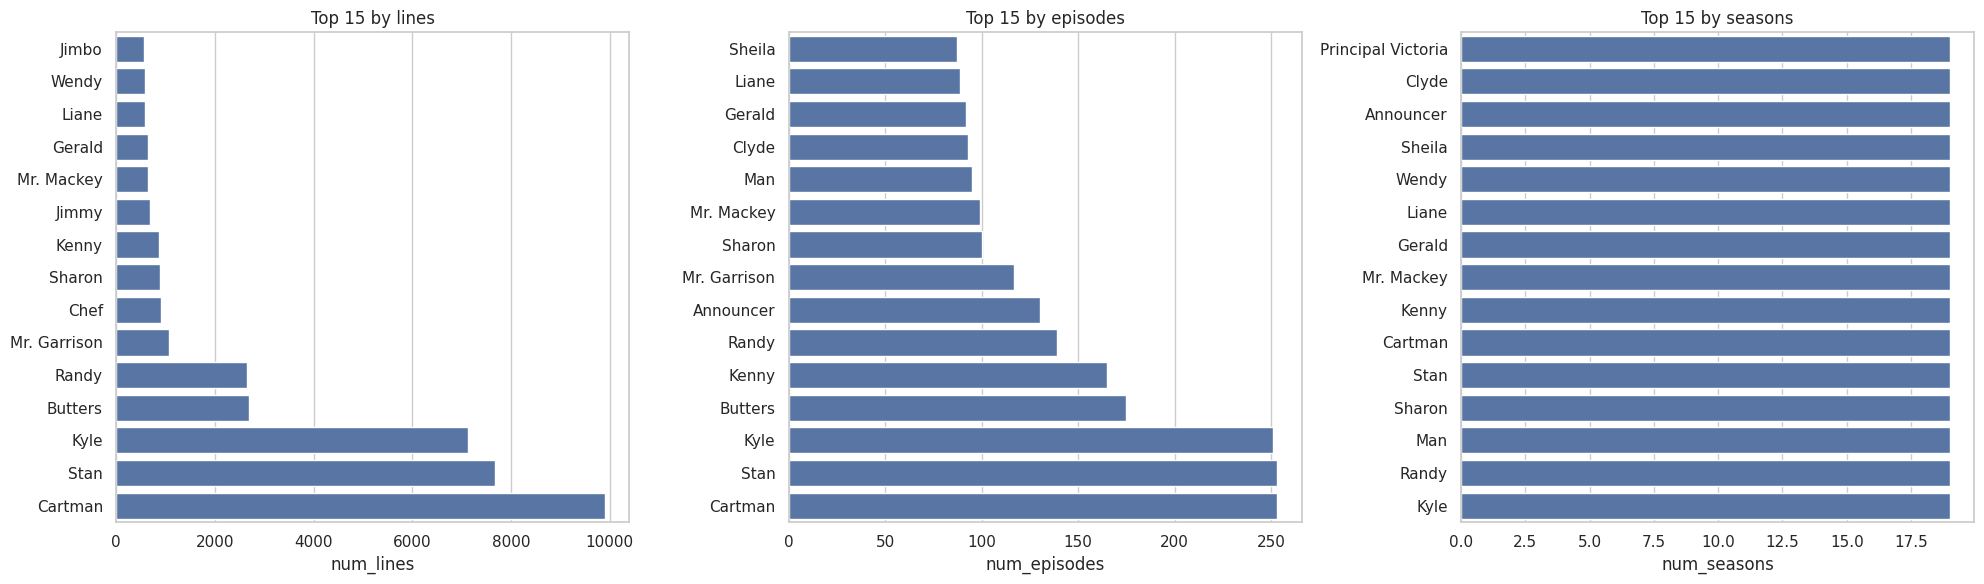

In [54]:
TOP_N = 15

# Prepare top-15 tables (sorted ascending for nice horizontal bars)
top_lines = summary.sort_values("num_lines", ascending=False).head(TOP_N).sort_values("num_lines", ascending=True)
top_eps   = summary.sort_values("num_episodes", ascending=False).head(TOP_N).sort_values("num_episodes", ascending=True)
top_seas  = summary.sort_values("num_seasons", ascending=False).head(TOP_N).sort_values("num_seasons", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=top_lines, y="Character", x="num_lines", ax=axes[0])
axes[0].set_title(f"Top {TOP_N} by lines")
axes[0].set_xlabel("num_lines")
axes[0].set_ylabel("")

sns.barplot(data=top_eps, y="Character", x="num_episodes", ax=axes[1])
axes[1].set_title(f"Top {TOP_N} by episodes")
axes[1].set_xlabel("num_episodes")
axes[1].set_ylabel("")

sns.barplot(data=top_seas, y="Character", x="num_seasons", ax=axes[2])
axes[2].set_title(f"Top {TOP_N} by seasons")
axes[2].set_xlabel("num_seasons")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

# Sweet spot coverage
---

In [55]:
## data frame
total_lines = df_clean.shape[0]
total_episodes = df_clean[["Season", "Episode"]].drop_duplicates().shape[0]
total_seasons = df_clean["Season"].nunique()

s_sorted = summary.sort_values("num_lines", ascending=False).reset_index(drop=True)
max_k = len(s_sorted)

# For each character: set of episodes + seasons they appear in
char_to_episodes = (
    df_clean[["Character", "Season", "Episode"]]
    .drop_duplicates()
    .groupby("Character")
    .apply(lambda x: set(map(tuple, x[["Season", "Episode"]].values)))
    .to_dict()
)

char_to_seasons = (
    df_clean[["Character", "Season"]]
    .drop_duplicates()
    .groupby("Character")["Season"]
    .apply(set)
    .to_dict()
)

coverage_records = []
episodes_union = set()
seasons_union = set()
lines_cum = 0

for k in range(1, max_k + 1):
    c = s_sorted.loc[k - 1, "Character"]
    lines_cum += int(s_sorted.loc[k - 1, "num_lines"])
    episodes_union |= char_to_episodes.get(c, set())
    seasons_union |= char_to_seasons.get(c, set())

    coverage_records.append(
        {
            "k": k,
            "line_coverage": lines_cum / total_lines,
            "episode_coverage": len(episodes_union) / total_episodes,
            "season_coverage": len(seasons_union) / total_seasons,
        }
    )

coverage_df = pd.DataFrame(coverage_records)
coverage_df.head()

/tmp/ipython-input-2032112599.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: set(map(tuple, x[["Season", "Episode"]].values)))


,k,line_coverage,episode_coverage,season_coverage
0,1,0.137280,0.947566,1.0
1,2,0.243649,0.970037,1.0
2,3,0.342610,0.973783,1.0
3,4,0.379889,0.977528,1.0
4,5,0.416682,0.981273,1.0


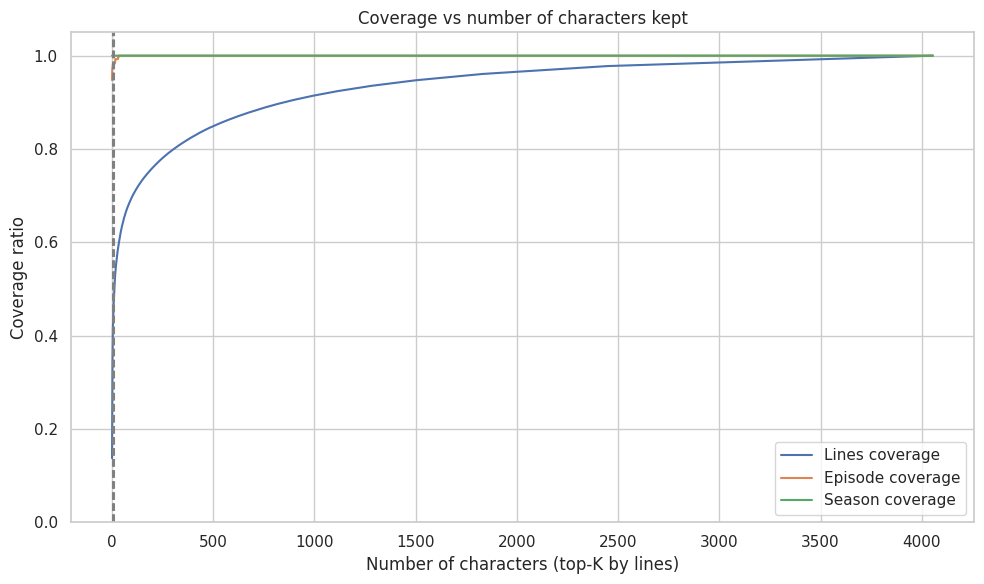

In [57]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=coverage_df, x="k", y="line_coverage", label="Lines coverage")
sns.lineplot(data=coverage_df, x="k", y="episode_coverage", label="Episode coverage")
sns.lineplot(data=coverage_df, x="k", y="season_coverage", label="Season coverage")

plt.axvline(8, linestyle="--", color="gray")
plt.axvline(12, linestyle="--", color="gray")

plt.title("Coverage vs number of characters kept")
plt.xlabel("Number of characters (top-K by lines)")
plt.ylabel("Coverage ratio")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## Sweet spot plot zoom (k <= 60)

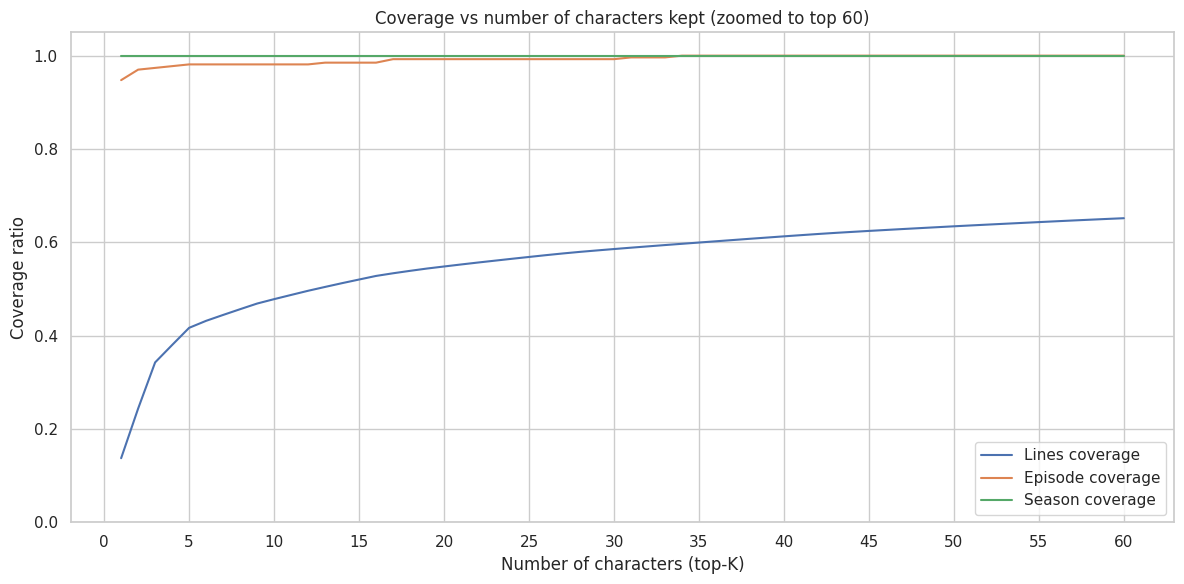

In [62]:
# %%
K_MAX = 60
zoom_df = coverage_df[coverage_df["k"] <= min(K_MAX, max_k)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=zoom_df, x="k", y="line_coverage", label="Lines coverage")
sns.lineplot(data=zoom_df, x="k", y="episode_coverage", label="Episode coverage")
sns.lineplot(data=zoom_df, x="k", y="season_coverage", label="Season coverage")

plt.xticks(list(range(0, int(zoom_df["k"].max()) + 1, 5)))

for kk in range(K_MAX, 10):
    if kk <= zoom_df["k"].max():
        plt.axvline(kk, linestyle="--", alpha=0.35)

plt.title("Coverage vs number of characters kept (zoomed to top 60)")
plt.xlabel("Number of characters (top-K)")
plt.ylabel("Coverage ratio")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## Helper function : choose based on coverage

In [66]:
def choose_k(coverage_df: pd.DataFrame, target_lines=0.85, target_episodes=0.80, target_seasons=1.0) -> int:
    mask = (
        (coverage_df["line_coverage"] >= target_lines) &
        (coverage_df["episode_coverage"] >= target_episodes) &
        (coverage_df["season_coverage"] >= target_seasons)
    )
    if mask.any():
        return int(coverage_df.loc[mask, "k"].iloc[0])
    return int(coverage_df["k"].max())

chosen_k = choose_k(coverage_df, target_lines=0.6, target_episodes=0.80, target_seasons=1.0)
chosen_k

36

In [67]:
selected_characters = s_sorted.head(chosen_k)["Character"].tolist()
print("Chosen K:", chosen_k)
print("Selected characters:", selected_characters)

Chosen K: 36
Selected characters: ['Cartman', 'Stan', 'Kyle', 'Butters', 'Randy', 'Mr. Garrison', 'Chef', 'Sharon', 'Kenny', 'Jimmy', 'Mr. Mackey', 'Gerald', 'Liane', 'Wendy', 'Jimbo', 'Sheila', 'Announcer', 'Stephen', 'Craig', 'Clyde', 'Jesus', 'Principal Victoria', 'Linda', 'Token', 'Mrs. Garrison', 'Terrance', 'Tweek', 'Mayor', 'Phillip', 'Bebe', 'Man', 'Woman', 'Satan', 'Michael', 'Ike', 'Shelly']


In [68]:
df_model = df_clean[df_clean["Character"].isin(selected_characters)].copy()
df_model.shape

(43405, 4)

In [71]:
df_model

,Season,Episode,Character,Line
1,1,1,Kyle,"Ah, damn it! My little brother's trying to fol..."
2,1,1,Ike,Zeeponanner.
3,1,1,Kyle,"Ike, you can't come to school with me."
4,1,1,Cartman,"Yeah, go home you little dildo."
5,1,1,Kyle,"Dude, don't call my brother a dildo!"
...,...,...,...,...
73133,19,10,Randy,"Well, I guess there's just one last thing to t..."
73134,19,10,Randy,Why did it have to be like this?! Why couldn't...
73135,19,10,Sharon,"Randy, you're yelling at a Whole Foods."
73136,19,10,Randy,"Go on, get outta here! We know! Others will kn..."


# Conclusion
The EDA shows that ranking characters by number of dialogue lines is a strong and practical way to select representative characters. The most frequent characters rapidly increase not only line coverage, but also episode and season coverage. This suggests that line frequency can be used as the primary ranking criterion, while episode and season coverage serve as validation checks to ensure that the selected characters remain broadly representative of the dataset.